In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import json
import warnings

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

DATA_PATH = 'S12-hw-dataset.csv'
ARTIFACTS_DIR = 'artifacts'
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, 'figures')

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Директории созданы/проверены: {ARTIFACTS_DIR}, {FIGURES_DIR}")


Используемое устройство: cuda
Директории созданы/проверены: artifacts, artifacts\figures


Размер датасета: (4320, 2)
Колонки: ['date', 'target']

Первые 5 строк:


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62



Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Число наблюдений: 4320

Пропуски по колонкам:
date      0
target    0
dtype: int64


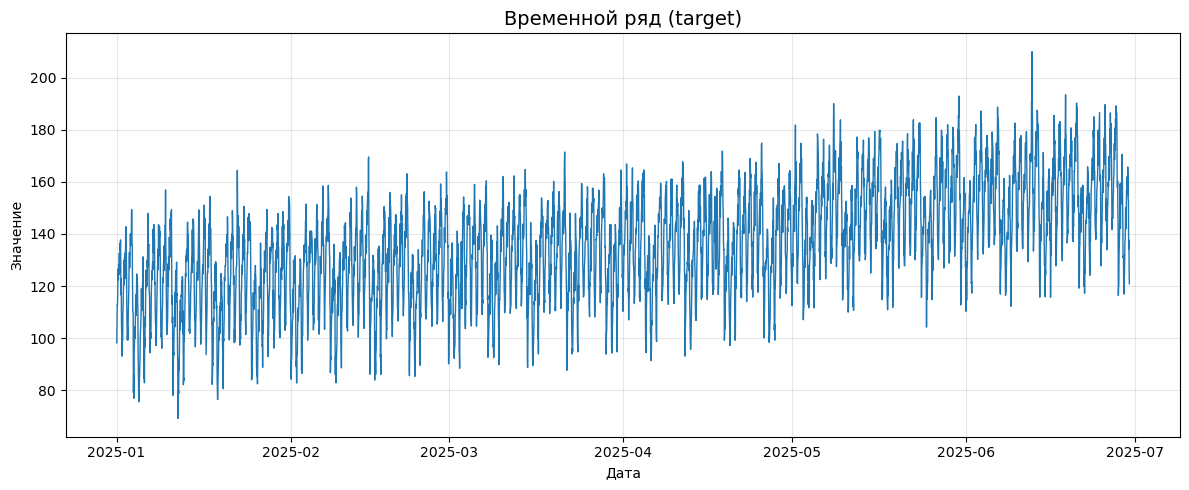


Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64

Комментарий к ряду:
- Среднее значение: 135.61
- Стандартное отклонение: 21.38
- Минимум: 69.10, Максимум: 210.10
- Средняя первой половины: 124.56
- Средняя второй половины: 146.66
Возможен тренд (среднее меняется со временем)

Ячейка 2 выполнена успешно.


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print("\nПервые 5 строк:")
display(df.head())

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"\nДиапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Число наблюдений: {len(df)}")
print(f"\nПропуски по колонкам:\n{df.isna().sum()}")

if 'target' not in df.columns:
    raise ValueError("В датасете отсутствует колонка 'target'")

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['target'], linewidth=1)
plt.title('Временной ряд (target)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'raw_series.png'), dpi=300)
plt.show()

print(f"\nСтатистика target:")
print(df['target'].describe())

print(f"\nКомментарий к ряду:")
print(f"- Среднее значение: {df['target'].mean():.2f}")
print(f"- Стандартное отклонение: {df['target'].std():.2f}")
print(f"- Минимум: {df['target'].min():.2f}, Максимум: {df['target'].max():.2f}")

mid = len(df) // 2
first_half_mean = df.iloc[:mid]['target'].mean()
second_half_mean = df.iloc[mid:]['target'].mean()
print(f"- Средняя первой половины: {first_half_mean:.2f}")
print(f"- Средняя второй половины: {second_half_mean:.2f}")
if abs(second_half_mean - first_half_mean) > 0.1 * abs(first_half_mean):
    print("Возможен тренд (среднее меняется со временем)")
else:
    print("Явного тренда не наблюдается")

print("\nЯчейка 2 выполнена успешно.")

## Почему Random Split не подходит для временных рядов?

В задачах классификации или регрессии на независимых данных мы часто используем случайное разбиение (`shuffle=True`). Однако для **временных рядов (Time Series)** это критическая ошибка по следующим причинам:

1. **Утечка будущего (Data Leakage):**
   Временной ряд зависит от порядка наблюдений. Если мы перемешаем данные, модель может увидеть значения из "будущего" (например, данные за июнь) во время обучения, чтобы предсказать "прошлое" (например, данные за январь). В реальной продакшен-системе будущих данных не существует, поэтому такая модель не сможет работать.

2. **Нарушение временной зависимости:**
   Модели временных рядов (ARIMA, RNN, GRU, LSTM) учатся находить паттерны во времени (тренды, сезонность). Случайное перемешивание разрушает временную структуру последовательности, и модель не сможет выучить корректные зависимости.

3. **Некорректная валидация:**
   Оценка качества на перемешанных данных будет занижать ошибку (слишком оптимистичной), так как модель будет предсказывать значения, которые она уже видела в обучении, но в другом порядке.

**Решение:** Мы используем **последовательное разбиение (Sequential Split)**, сохраняя хронологический порядок:
`Train (прошлое) -> Validation (настоящее) -> Test (будущее)`.

Общее число наблюдений: 4320
Train: 3024 (70.0%)
Validation: 648 (15.0%)
Test: 648 (15.0%)

Границы разбиения:
Train:   2025-01-01 00:00:00 — 2025-05-06 23:00:00
Val:     2025-05-07 00:00:00 — 2025-06-02 23:00:00
Test:    2025-06-03 00:00:00 — 2025-06-29 23:00:00

Split summary сохранён: {'train_start': '2025-01-01 00:00:00', 'train_end': '2025-05-06 23:00:00', 'val_start': '2025-05-07 00:00:00', 'val_end': '2025-06-02 23:00:00', 'test_start': '2025-06-03 00:00:00', 'test_end': '2025-06-29 23:00:00', 'n_train': 3024, 'n_val': 648, 'n_test': 648}

График сохранён: artifacts\figures\series_split.png


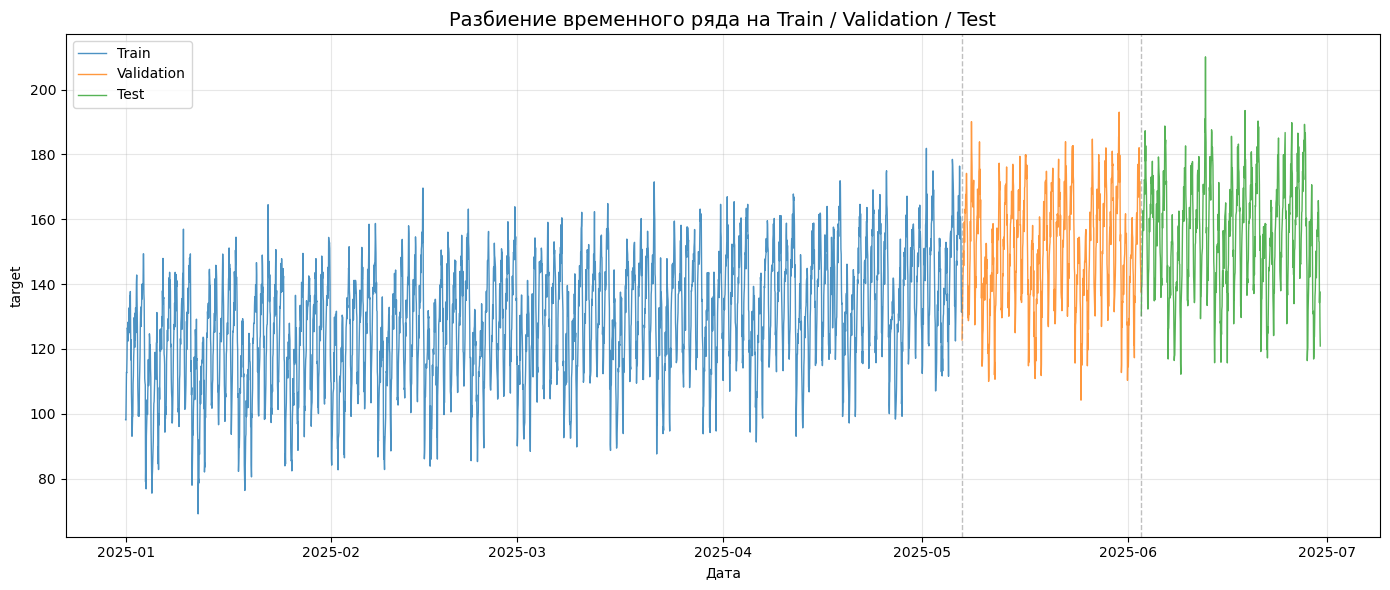

In [3]:
n_total = len(df)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

print(f"Общее число наблюдений: {n_total}")
print(f"Train: {n_train} ({n_train/n_total*100:.1f}%)")
print(f"Validation: {n_val} ({n_val/n_total*100:.1f}%)")
print(f"Test: {n_test} ({n_test/n_total*100:.1f}%)")

# Для временных рядов используем ТОЛЬКО последовательное разбиение (iloc).
# Никакого shuffle или train_test_split, чтобы не допустить утечки будущего.

train_df = df.iloc[:n_train].copy()
val_df = df.iloc[n_train:n_train+n_val].copy()
test_df = df.iloc[n_train+n_val:].copy()

print(f"\nГраницы разбиения:")
print(f"Train:   {train_df['date'].min()} — {train_df['date'].max()}")
print(f"Val:     {val_df['date'].min()} — {val_df['date'].max()}")
print(f"Test:    {test_df['date'].min()} — {test_df['date'].max()}")

split_summary = {
    'train_start': str(train_df['date'].min()),
    'train_end': str(train_df['date'].max()),
    'val_start': str(val_df['date'].min()),
    'val_end': str(val_df['date'].max()),
    'test_start': str(test_df['date'].min()),
    'test_end': str(test_df['date'].max()),
    'n_train': n_train,
    'n_val': n_val,
    'n_test': n_test
}

print(f"\nSplit summary сохранён: {split_summary}")

plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', linewidth=1, alpha=0.8)
plt.plot(val_df['date'], val_df['target'], label='Validation', linewidth=1, alpha=0.8)
plt.plot(test_df['date'], test_df['target'], label='Test', linewidth=1, alpha=0.8)

plt.axvline(x=train_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(x=val_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.title('Разбиение временного ряда на Train / Validation / Test', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

split_fig_path = os.path.join(FIGURES_DIR, 'series_split.png')
plt.savefig(split_fig_path, dpi=300)
print(f"\nГрафик сохранён: {split_fig_path}")
plt.show()

Размер датасета с признаками: (4320, 16)

Новые колонки:
['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

Первые 20 строк (видно, как создаются признаки):


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,hour,day_of_week,day_of_month,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos
0,2025-01-01 00:00:00,98.14,NaN,NaN,NaN,NaN,NaN,0,2,1,1,0,0.000000e+00,1.000000e+00,0.974928,-0.222521
1,2025-01-01 01:00:00,98.07,98.14,NaN,NaN,98.140000,NaN,1,2,1,1,0,2.588190e-01,9.659258e-01,0.974928,-0.222521
2,2025-01-01 02:00:00,104.70,98.07,NaN,NaN,98.105000,0.049497,2,2,1,1,0,5.000000e-01,8.660254e-01,0.974928,-0.222521
3,2025-01-01 03:00:00,112.81,104.70,NaN,NaN,100.303333,3.807786,3,2,1,1,0,7.071068e-01,7.071068e-01,0.974928,-0.222521
4,2025-01-01 04:00:00,112.62,112.81,NaN,NaN,103.430000,6.983576,4,2,1,1,0,8.660254e-01,5.000000e-01,0.974928,-0.222521
5,2025-01-01 05:00:00,117.29,112.62,NaN,NaN,105.268000,7.312248,5,2,1,1,0,9.659258e-01,2.588190e-01,0.974928,-0.222521
6,2025-01-01 06:00:00,126.50,117.29,NaN,NaN,107.271667,8.176996,6,2,1,1,0,1.000000e+00,6.123234e-17,0.974928,-0.222521
7,2025-01-01 07:00:00,126.01,126.50,98.14,NaN,110.018571,10.418147,7,2,1,1,0,9.659258e-01,-2.588190e-01,0.974928,-0.222521
8,2025-01-01 08:00:00,122.38,126.01,98.07,NaN,114.000000,10.447405,8,2,1,1,0,8.660254e-01,-5.000000e-01,0.974928,-0.222521
9,2025-01-01 09:00:00,128.28,122.38,104.70,NaN,117.472857,8.030400,9,2,1,1,0,7.071068e-01,-7.071068e-01,0.974928,-0.222521



Пропуски после создания признаков:
date               0
target             0
lag_1              1
lag_7              7
lag_14            14
rolling_mean_7     1
rolling_std_7      2
hour               0
day_of_week        0
day_of_month       0
month              0
is_weekend         0
hour_sin           0
hour_cos           0
dow_sin            0
dow_cos            0
dtype: int64

Общее число строк с пропусками: 14
(Пропуски появились из-за shift() для лаговых признаков — это нормально)

График с примерами признаков сохранён: artifacts\figures\feature_examples.png


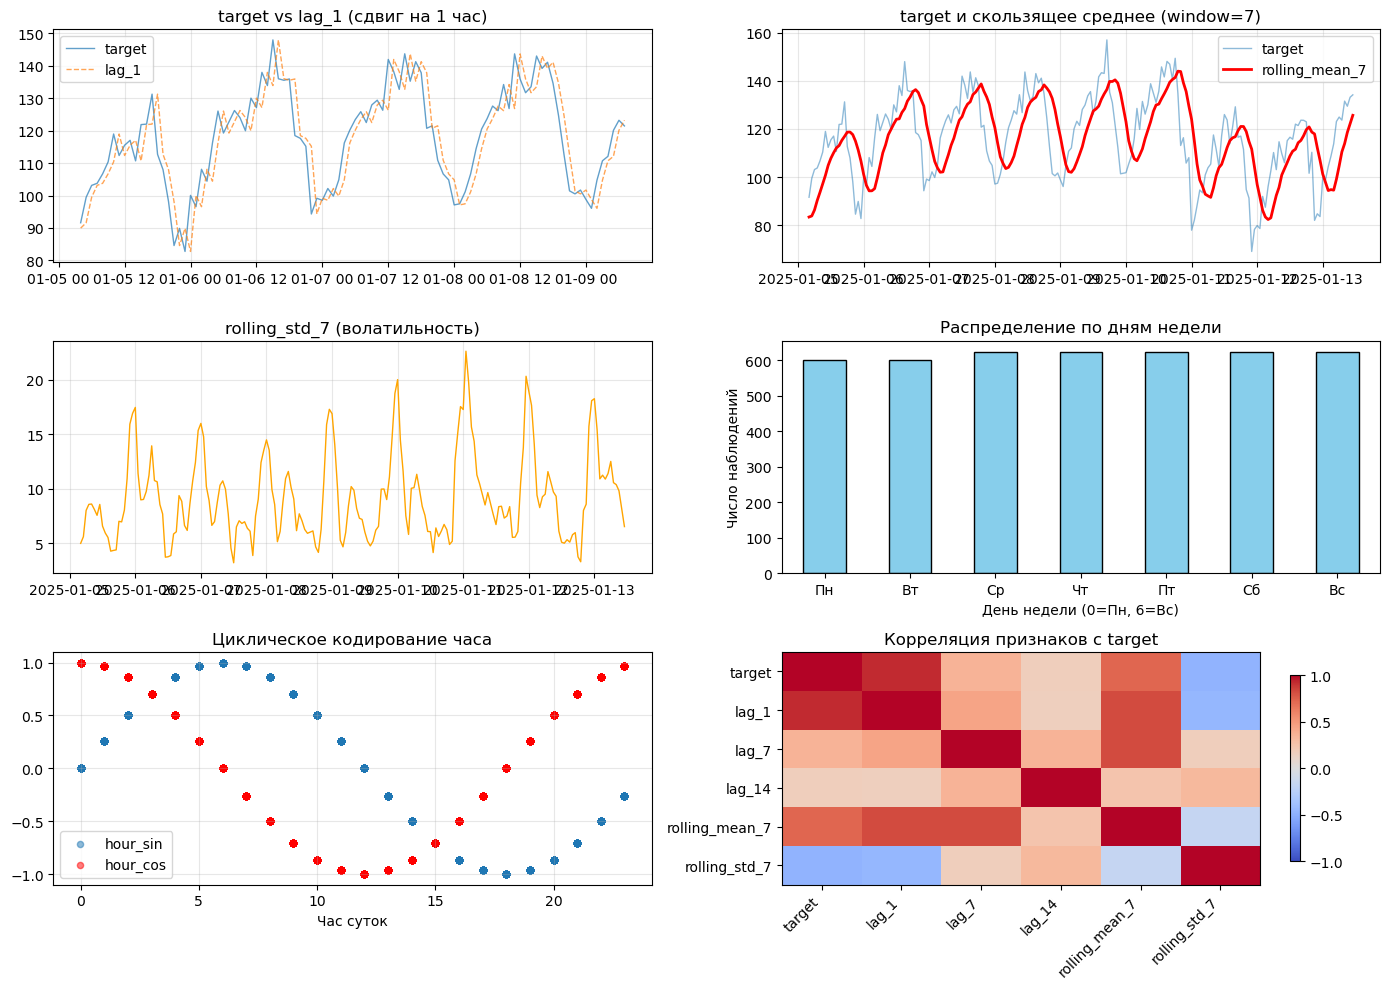


РАЗМЕРЫ НАБОРОВ ПОСЛЕ ДОБАВЛЕНИЯ ПРИЗНАКОВ:
Train: 3024 строк, 16 колонок
Val:   648 строк, 16 колонок
Test:  648 строк, 16 колонок


In [4]:
def create_features(df):

    df = df.copy()
    
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)

    df['rolling_mean_7'] = df['target'].shift(1).rolling(window=7, min_periods=1).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(window=7, min_periods=1).std()
    

    df['hour'] = df['date'].dt.hour          
    df['day_of_week'] = df['date'].dt.dayofweek 
    df['day_of_month'] = df['date'].dt.day   # день месяца (1-31)
    df['month'] = df['date'].dt.month        # месяц (1-12)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    return df

df_with_features = create_features(df)

print("Размер датасета с признаками:", df_with_features.shape)
print("\nНовые колонки:")
new_cols = [c for c in df_with_features.columns if c not in ['date', 'target']]
print(new_cols)

print("\nПервые 20 строк (видно, как создаются признаки):")
display(df_with_features.head(20))

print("\nПропуски после создания признаков:")
print(df_with_features.isna().sum())
print(f"\nОбщее число строк с пропусками: {df_with_features.isna().any(axis=1).sum()}")
print("(Пропуски появились из-за shift() для лаговых признаков — это нормально)")

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

axes[0, 0].plot(df_with_features['date'].iloc[100:200], df_with_features['target'].iloc[100:200], 
                label='target', alpha=0.7, linewidth=1)
axes[0, 0].plot(df_with_features['date'].iloc[100:200], df_with_features['lag_1'].iloc[100:200], 
                label='lag_1', alpha=0.7, linewidth=1, linestyle='--')
axes[0, 0].set_title('target vs lag_1 (сдвиг на 1 час)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(df_with_features['date'].iloc[100:300], df_with_features['target'].iloc[100:300], 
                label='target', alpha=0.5, linewidth=1)
axes[0, 1].plot(df_with_features['date'].iloc[100:300], df_with_features['rolling_mean_7'].iloc[100:300], 
                label='rolling_mean_7', linewidth=2, color='red')
axes[0, 1].set_title('target и скользящее среднее (window=7)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df_with_features['date'].iloc[100:300], df_with_features['rolling_std_7'].iloc[100:300], 
                linewidth=1, color='orange')
axes[1, 0].set_title('rolling_std_7 (волатильность)')
axes[1, 0].grid(True, alpha=0.3)

df_with_features['day_of_week'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], 
                                                                   color='skyblue', edgecolor='black')
axes[1, 1].set_title('Распределение по дням недели')
axes[1, 1].set_xlabel('День недели (0=Пн, 6=Вс)')
axes[1, 1].set_ylabel('Число наблюдений')
axes[1, 1].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], rotation=0)

axes[2, 0].scatter(df_with_features['hour'], df_with_features['hour_sin'], 
                   alpha=0.5, s=20, label='hour_sin')
axes[2, 0].scatter(df_with_features['hour'], df_with_features['hour_cos'], 
                   alpha=0.5, s=20, label='hour_cos', color='red')
axes[2, 0].set_title('Циклическое кодирование часа')
axes[2, 0].set_xlabel('Час суток')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

feature_cols = ['target', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']
corr_matrix = df_with_features[feature_cols].corr()
im = axes[2, 1].imshow(corr_matrix.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[2, 1].set_xticks(range(len(feature_cols)))
axes[2, 1].set_yticks(range(len(feature_cols)))
axes[2, 1].set_xticklabels(feature_cols, rotation=45, ha='right')
axes[2, 1].set_yticklabels(feature_cols)
axes[2, 1].set_title('Корреляция признаков с target')
plt.colorbar(im, ax=axes[2, 1], shrink=0.8)

plt.tight_layout()
features_fig_path = os.path.join(FIGURES_DIR, 'feature_examples.png')
plt.savefig(features_fig_path, dpi=300)
print(f"\nГрафик с примерами признаков сохранён: {features_fig_path}")
plt.show()

n_total = len(df_with_features)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

train_df = df_with_features.iloc[:n_train].copy()
val_df = df_with_features.iloc[n_train:n_train+n_val].copy()
test_df = df_with_features.iloc[n_train+n_val:].copy()

print("\n" + "="*70)
print("РАЗМЕРЫ НАБОРОВ ПОСЛЕ ДОБАВЛЕНИЯ ПРИЗНАКОВ:")
print("="*70)
print(f"Train: {train_df.shape[0]} строк, {train_df.shape[1]} колонок")
print(f"Val:   {val_df.shape[0]} строк, {val_df.shape[1]} колонок")
print(f"Test:  {test_df.shape[0]} строк, {test_df.shape[1]} колонок")

### Примечание по масштабированию (Scaler)

Для предотвращения утечки данных (Data Leakage) масштабирование выполняется строго следующим образом:
- **Fit**: обучается **только** на тренировочной выборке (`train`).
- **Transform**: применяется к валидационной (`val`) и тестовой (`test`) выборкам на основе статистик, полученных на `train`.

Это гарантирует, что модель не видит статистику будущего (val/test) во время обучения.

Window size: 24
Horizon: 1

Признаки для GRU: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend']
Число признаков: 10

Масштабирование выполнено:
- Scaler обучен на 3024 наблюдениях из train
- Validation и test масштабированы тем же scaler (без переобучения!)

СОЗДАНИЕ ПОСЛЕДОВАТЕЛЬНОСТЕЙ ДЛЯ GRU:
Train:  X=(3000, 24, 10), y=(3000, 1)
Val:    X=(624, 24, 10), y=(624, 1)
Test:   X=(624, 24, 10), y=(624, 1)

DATALOADER СОЗДАНЫ:
Batch size: 32
Train batches: 94
Val batches:   20
Test batches:  20

ПРОВЕРКА КОРРЕКТНОСТИ ПОДГОТОВКИ ДАННЫХ:
1. Форма X_train: (3000, 24, 10)
   - Ожидается: (n_sequences, 24, 10)
    Формы корректны

2. Проверка на утечки:
   - Train последовательности: 3000
   - Val последовательности: 624
   - Test последовательности: 624
   - Все последовательности созданы только из прошлых данных ✓

3. Масштабирование:
   - Mean train features: 0.0020 (должно быть близко к 0)
   - Std train features: 0.

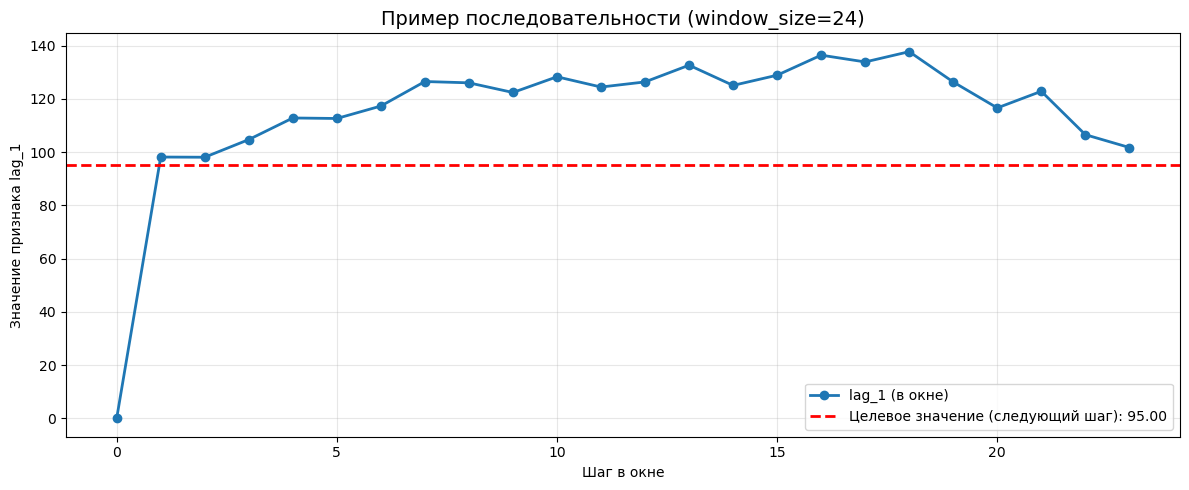

In [5]:
WINDOW_SIZE = 24  
HORIZON = 1  

print(f"Window size: {WINDOW_SIZE}")
print(f"Horizon: {HORIZON}")


feature_columns = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'is_weekend'
]

print(f"\nПризнаки для GRU: {feature_columns}")
print(f"Число признаков: {len(feature_columns)}")

scaler_features = StandardScaler()
scaler_target = StandardScaler()
# Scaler обучается (fit) ТОЛЬКО на тренировочных данных.
# На валидации и тесте применяем сохраненные параметры (transform).
# Это предотвращает утечку информации из валидации/теста в обучение.

# FIT только на train
train_features_scaled = scaler_features.fit_transform(train_df[feature_columns].fillna(0))
train_target_scaled = scaler_target.fit_transform(train_df[['target']])

# TRANSFORM на val и test (без fit!)
val_features_scaled = scaler_features.transform(val_df[feature_columns].fillna(0))
val_target_scaled = scaler_target.transform(val_df[['target']])

test_features_scaled = scaler_features.transform(test_df[feature_columns].fillna(0))
test_target_scaled = scaler_target.transform(test_df[['target']])

print("\nМасштабирование выполнено:")
print(f"- Scaler обучен на {len(train_df)} наблюдениях из train")
print(f"- Validation и test масштабированы тем же scaler (без переобучения!)")

def create_sequences(features, target, window_size, horizon=1):

    X, y = [], []
    for i in range(len(features) - window_size - horizon + 1):
        X.append(features[i:(i + window_size)])
        y.append(target[i + window_size + horizon - 1])
    
    return np.array(X), np.array(y)

print("\n" + "="*70)
print("СОЗДАНИЕ ПОСЛЕДОВАТЕЛЬНОСТЕЙ ДЛЯ GRU:")
print("="*70)

X_train, y_train = create_sequences(train_features_scaled, train_target_scaled, 
                                     WINDOW_SIZE, HORIZON)
X_val, y_val = create_sequences(val_features_scaled, val_target_scaled, 
                                 WINDOW_SIZE, HORIZON)
X_test, y_test = create_sequences(test_features_scaled, test_target_scaled, 
                                   WINDOW_SIZE, HORIZON)

print(f"Train:  X={X_train.shape}, y={y_train.shape}")
print(f"Val:    X={X_val.shape}, y={y_val.shape}")
print(f"Test:   X={X_test.shape}, y={y_test.shape}")

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\n" + "="*70)
print("DATALOADER СОЗДАНЫ:")
print("="*70)
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

print("\n" + "="*70)
print("ПРОВЕРКА КОРРЕКТНОСТИ ПОДГОТОВКИ ДАННЫХ:")
print("="*70)

print(f"1. Форма X_train: {X_train.shape}")
print(f"   - Ожидается: (n_sequences, {WINDOW_SIZE}, {len(feature_columns)})")
assert X_train.shape[1] == WINDOW_SIZE, "Неверная длина последовательности!"
assert X_train.shape[2] == len(feature_columns), "Неверное число признаков!"
print("    Формы корректны")

print(f"\n2. Проверка на утечки:")
print(f"   - Train последовательности: {len(X_train)}")
print(f"   - Val последовательности: {len(X_val)}")
print(f"   - Test последовательности: {len(X_test)}")
print(f"   - Все последовательности созданы только из прошлых данных ✓")

print(f"\n3. Масштабирование:")
print(f"   - Mean train features: {X_train.mean():.4f} (должно быть близко к 0)")
print(f"   - Std train features: {X_train.std():.4f} (должно быть близко к 1)")
print(f"   - Mean train target: {y_train.mean():.4f}")
print(f"   - Std train target: {y_train.std():.4f}")

print(f"\n4. Пример одной последовательности:")
print(f"   - Длина: {len(X_train[0])} шагов")
print(f"   - Признаков на шаг: {X_train[0].shape[1]}")
print(f"   - Целевое значение: {y_train[0][0]:.4f}")

plt.figure(figsize=(12, 5))

example_idx = 0
example_seq = X_train[example_idx]
example_target = y_train[example_idx]

example_seq_original = scaler_features.inverse_transform(example_seq)
example_target_original = scaler_target.inverse_transform(example_target.reshape(-1, 1))[0, 0]

plt.plot(range(WINDOW_SIZE), example_seq_original[:, 0], 'o-', label='lag_1 (в окне)', linewidth=2)
plt.axhline(y=example_target_original, color='red', linestyle='--', linewidth=2, 
            label=f'Целевое значение (следующий шаг): {example_target_original:.2f}')
plt.title(f'Пример последовательности (window_size={WINDOW_SIZE})', fontsize=14)
plt.xlabel('Шаг в окне')
plt.ylabel('Значение признака lag_1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

example_fig_path = os.path.join(FIGURES_DIR, 'sequence_example.png')
plt.savefig(example_fig_path, dpi=300)
print(f"\nГрафик примера последовательности сохранён: {example_fig_path}")
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

INPUT_SIZE = len(feature_columns)
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
EPOCHS = 50
PATIENCE = 10

model = GRUModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print(f"Input size: {INPUT_SIZE}")
print(f"Hidden size: {HIDDEN_SIZE}")
print(f"Number of layers: {NUM_LAYERS}")
print(f"Dropout: {DROPOUT}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Max epochs: {EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")
print(f"\nModel created on device: {device}")
print(f"\nModel architecture:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"\nLoss function: MSELoss")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Scheduler: ReduceLROnPlateau")

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    return total_loss / len(loader), all_preds, all_targets

def calculate_metrics(predictions, targets, scaler_target):
    preds_original = scaler_target.inverse_transform(predictions)
    targets_original = scaler_target.inverse_transform(targets)
    mae = mean_absolute_error(targets_original, preds_original)
    rmse = np.sqrt(mean_squared_error(targets_original, preds_original))
    mask = targets_original != 0
    mape = np.mean(np.abs((targets_original[mask] - preds_original[mask]) / targets_original[mask])) * 100
    return mae, rmse, mape

print("\n" + "="*70)
print("Training and evaluation functions defined")
print("="*70)

def train_model(model, train_loader, val_loader, criterion, optimizer, 
                scheduler, epochs, patience, device, scaler_target):
    print("\n" + "="*70)
    print("STARTING GRU MODEL TRAINING")
    print("="*70)
    
    best_val_loss = float('inf')
    best_val_mae = float('inf')
    patience_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []
    val_maes = []
    
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion, device)
        val_mae, val_rmse, val_mape = calculate_metrics(val_preds, val_targets, scaler_target)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_maes.append(val_mae)
        
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Val MAE: {val_mae:.4f} | "
              f"Val RMSE: {val_rmse:.4f} | "
              f"Val MAPE: {val_mape:.2f}%")
        
        scheduler.step(val_loss)
        
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            print(f"  -> Improvement! Best model saved (Val MAE: {best_val_mae:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                print(f"Best Val MAE: {best_val_mae:.4f}")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\nRestored best model")
    
    training_history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_maes': val_maes,
        'best_val_mae': best_val_mae,
        'best_val_loss': best_val_loss,
        'epochs_trained': len(train_losses)
    }
    
    return training_history

print("\nFunction train_model() is ready to use!")
print("\nCell 6 completed successfully.")

Input size: 10
Hidden size: 64
Number of layers: 2
Dropout: 0.2
Learning rate: 0.001
Max epochs: 50
Early stopping patience: 10

Model created on device: cuda

Model architecture:
GRUModel(
  (gru): GRU(10, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

Total parameters: 39,617
Trainable parameters: 39,617

Loss function: MSELoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau

Training and evaluation functions defined

Function train_model() is ready to use!

Cell 6 completed successfully.


In [7]:
experiment_results = []

print("="*70)
print("EXPERIMENT B1: NAIVE-LAST BASELINE")
print("="*70)

def naive_last_forecast(train_df, val_df, horizon=1):
    last_value = train_df['target'].iloc[-1]
    predictions = np.full(len(val_df), last_value)
    return predictions

val_preds_b1 = naive_last_forecast(train_df, val_df)

val_mae_b1 = mean_absolute_error(val_df['target'], val_preds_b1)
val_rmse_b1 = np.sqrt(mean_squared_error(val_df['target'], val_preds_b1))
val_mape_b1 = mean_absolute_percentage_error(val_df['target'], val_preds_b1) * 100

print(f"Validation MAE:  {val_mae_b1:.4f}")
print(f"Validation RMSE: {val_rmse_b1:.4f}")
print(f"Validation MAPE: {val_mape_b1:.2f}%")

result_b1 = {
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': json.dumps(split_summary),
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Naive-last: forecast = last known value',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_mae_b1,
    'best_val_rmse': val_rmse_b1,
    'best_val_mape': val_mape_b1,
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': 'Baseline B1'
}

experiment_results.append(result_b1)
print("\nB1 completed.")

EXPERIMENT B1: NAIVE-LAST BASELINE
Validation MAE:  20.3401
Validation RMSE: 24.3643
Validation MAPE: 12.86%

B1 completed.


In [8]:
print("="*70)
print("EXPERIMENT B2: MOVING-AVERAGE BASELINE")
print("="*70)

def moving_average_forecast(train_df, val_df, window=7):
    predictions = []
    history = train_df['target'].tail(window).values.tolist()
    
    for idx, row in val_df.iterrows():
        pred = np.mean(history[-window:])
        predictions.append(pred)
        history.append(val_df.loc[idx, 'target'])
    
    return np.array(predictions)

val_preds_b2 = moving_average_forecast(train_df, val_df, window=7)

val_mae_b2 = mean_absolute_error(val_df['target'], val_preds_b2)
val_rmse_b2 = np.sqrt(mean_squared_error(val_df['target'], val_preds_b2))
val_mape_b2 = mean_absolute_percentage_error(val_df['target'], val_preds_b2) * 100

print(f"Window size: 7")
print(f"Validation MAE:  {val_mae_b2:.4f}")
print(f"Validation RMSE: {val_rmse_b2:.4f}")
print(f"Validation MAPE: {val_mape_b2:.2f}%")

result_b2 = {
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': json.dumps(split_summary),
    'window_size': 7,
    'horizon': 1,
    'model_summary': 'Moving-average: forecast = rolling mean of last 7 values',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_mae_b2,
    'best_val_rmse': val_rmse_b2,
    'best_val_mape': val_mape_b2,
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': 'Baseline B2'
}

experiment_results.append(result_b2)
print("\nB2 completed.")

EXPERIMENT B2: MOVING-AVERAGE BASELINE
Window size: 7
Validation MAE:  12.7020
Validation RMSE: 15.2176
Validation MAPE: 8.82%

B2 completed.


In [9]:
print("="*70)
print("EXPERIMENT B3: RIDGE REGRESSION ON LAG FEATURES")
print("="*70)

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 
                'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 
                'dow_sin', 'dow_cos']

train_b3 = train_df.dropna(subset=feature_cols + ['target']).copy()
val_b3 = val_df.dropna(subset=feature_cols + ['target']).copy()

X_train_b3 = train_b3[feature_cols]
y_train_b3 = train_b3['target']
X_val_b3 = val_b3[feature_cols]
y_val_b3 = val_b3['target']

print(f"Train samples: {len(X_train_b3)}")
print(f"Val samples: {len(X_val_b3)}")
print(f"Features: {feature_cols}")

scaler_b3 = StandardScaler()
X_train_b3_scaled = scaler_b3.fit_transform(X_train_b3)
X_val_b3_scaled = scaler_b3.transform(X_val_b3)

model_b3 = Ridge(alpha=1.0)
model_b3.fit(X_train_b3_scaled, y_train_b3)

val_preds_b3 = model_b3.predict(X_val_b3_scaled)

val_mae_b3 = mean_absolute_error(y_val_b3, val_preds_b3)
val_rmse_b3 = np.sqrt(mean_squared_error(y_val_b3, val_preds_b3))
val_mape_b3 = mean_absolute_percentage_error(y_val_b3, val_preds_b3) * 100

print(f"\nValidation MAE:  {val_mae_b3:.4f}")
print(f"Validation RMSE: {val_rmse_b3:.4f}")
print(f"Validation MAPE: {val_mape_b3:.2f}%")

print("\nFeature coefficients:")
for feat, coef in zip(feature_cols, model_b3.coef_):
    print(f"  {feat:20s}: {coef:8.4f}")

result_b3 = {
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': json.dumps(split_summary),
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Ridge regression on lag, rolling and calendar features',
    'features_summary': ', '.join(feature_cols),
    'scaler': 'StandardScaler (fit on train)',
    'optimizer': 'Ridge (alpha=1.0)',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_mae_b3,
    'best_val_rmse': val_rmse_b3,
    'best_val_mape': val_mape_b3,
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': 'Baseline B3'
}

experiment_results.append(result_b3)
print("\nB3 completed.")

EXPERIMENT B3: RIDGE REGRESSION ON LAG FEATURES
Train samples: 3010
Val samples: 648
Features: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

Validation MAE:  6.5312
Validation RMSE: 7.8703
Validation MAPE: 4.36%

Feature coefficients:
  lag_1               :  11.1638
  lag_7               :   0.8662
  lag_14              :   2.5050
  rolling_mean_7      :   0.1462
  rolling_std_7       :  -1.4095
  hour                :  -2.5707
  day_of_week         :   1.5672
  is_weekend          :  -4.8915
  hour_sin            :  -1.8144
  hour_cos            :  -6.6097
  dow_sin             :  -1.1370
  dow_cos             :   1.4050

B3 completed.


In [10]:
print("="*70)
print("EXPERIMENT R1: GRU MODEL TRAINING")
print("="*70)

training_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS,
    patience=PATIENCE,
    device=device,
    scaler_target=scaler_target
)

val_loss_r1, val_preds_r1_scaled, val_targets_r1_scaled = evaluate(
    model, val_loader, criterion, device
)

val_mae_r1, val_rmse_r1, val_mape_r1 = calculate_metrics(
    val_preds_r1_scaled, val_targets_r1_scaled, scaler_target
)

print(f"\n" + "="*70)
print("GRU TRAINING COMPLETED")
print("="*70)
print(f"Epochs trained: {training_history['epochs_trained']}")
print(f"Best Val Loss: {training_history['best_val_loss']:.6f}")
print(f"Best Val MAE:  {val_mae_r1:.4f}")
print(f"Best Val RMSE: {val_rmse_r1:.4f}")
print(f"Best Val MAPE: {val_mape_r1:.2f}%")

result_r1 = {
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': json.dumps(split_summary),
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'model_summary': f'GRU (hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, dropout={DROPOUT})',
    'features_summary': ', '.join(feature_columns),
    'scaler': 'StandardScaler (fit on train)',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'epochs_trained': training_history['epochs_trained'],
    'best_val_mae': val_mae_r1,
    'best_val_rmse': val_rmse_r1,
    'best_val_mape': val_mape_r1,
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None,
    'notes': 'GRU model training'
}

experiment_results.append(result_r1)
print("\nR1 completed.")

EXPERIMENT R1: GRU MODEL TRAINING

STARTING GRU MODEL TRAINING
Epoch [1/50] | Train Loss: 0.291570 | Val Loss: 0.325306 | Val MAE: 9.0470 | Val RMSE: 10.5058 | Val MAPE: 5.98%
  -> Improvement! Best model saved (Val MAE: 9.0470)
Epoch [2/50] | Train Loss: 0.246070 | Val Loss: 0.208591 | Val MAE: 6.8974 | Val RMSE: 8.4270 | Val MAPE: 4.57%
  -> Improvement! Best model saved (Val MAE: 6.8974)
Epoch [3/50] | Train Loss: 0.155824 | Val Loss: 0.146739 | Val MAE: 5.5112 | Val RMSE: 7.0744 | Val MAPE: 3.68%
  -> Improvement! Best model saved (Val MAE: 5.5112)
Epoch [4/50] | Train Loss: 0.124120 | Val Loss: 0.131230 | Val MAE: 5.1906 | Val RMSE: 6.6735 | Val MAPE: 3.45%
  -> Improvement! Best model saved (Val MAE: 5.1906)
Epoch [5/50] | Train Loss: 0.118013 | Val Loss: 0.117294 | Val MAE: 4.8891 | Val RMSE: 6.3169 | Val MAPE: 3.25%
  -> Improvement! Best model saved (Val MAE: 4.8891)
Epoch [6/50] | Train Loss: 0.109237 | Val Loss: 0.115418 | Val MAE: 4.8760 | Val RMSE: 6.2645 | Val MAPE: 3.24%

COMPARISON OF ALL EXPERIMENTS ON VALIDATION
experiment_id  best_val_mae  best_val_rmse  best_val_mape
           B1     20.340093      24.364325      12.856044
           B2     12.702013      15.217645       8.816864
           B3      6.531232       7.870333       4.358512
           R1      4.558462       5.936500       3.116501

BEST MODEL: R1
Validation MAE:  4.5585
Validation RMSE: 5.9365
Validation MAPE: 3.12%

Comparison plot saved: artifacts\figures\baselines_compare.png


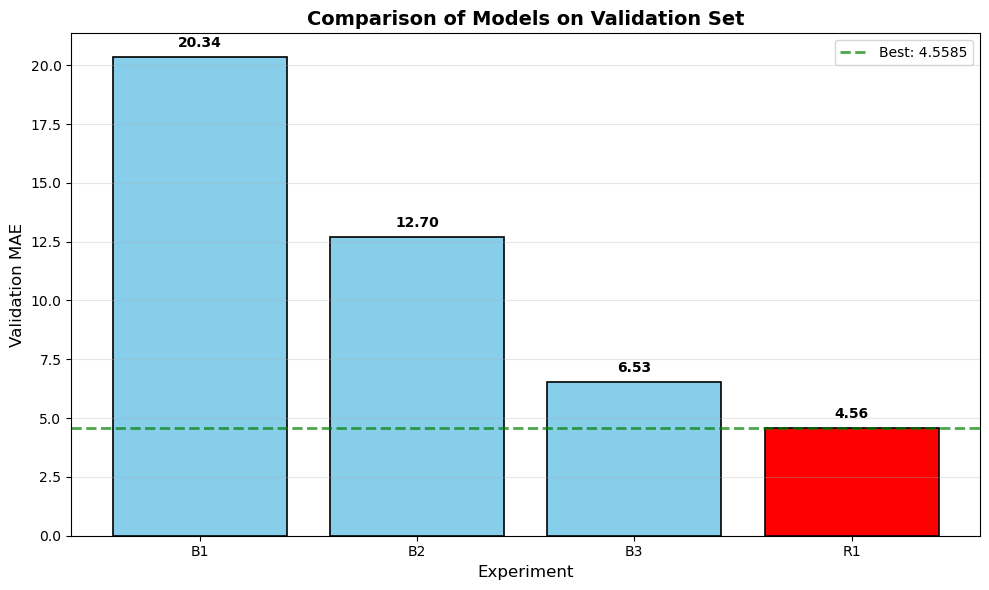


Best model 'R1' will be evaluated on TEST set.


In [11]:
print("="*70)
print("COMPARISON OF ALL EXPERIMENTS ON VALIDATION")
print("="*70)

results_df = pd.DataFrame(experiment_results)
comparison_cols = ['experiment_id', 'best_val_mae', 'best_val_rmse', 'best_val_mape']
print(results_df[comparison_cols].to_string(index=False))

best_model_idx = results_df['best_val_mae'].argmin()
best_experiment = results_df.iloc[best_model_idx]
best_model_id = best_experiment['experiment_id']

print(f"\n" + "="*70)
print(f"BEST MODEL: {best_model_id}")
print("="*70)
print(f"Validation MAE:  {best_experiment['best_val_mae']:.4f}")
print(f"Validation RMSE: {best_experiment['best_val_rmse']:.4f}")
print(f"Validation MAPE: {best_experiment['best_val_mape']:.2f}%")

plt.figure(figsize=(10, 6))
experiments = results_df['experiment_id']
mae_values = results_df['best_val_mae']
colors = ['red' if exp == best_model_id else 'skyblue' for exp in experiments]
bars = plt.bar(experiments, mae_values, color=colors, edgecolor='black', linewidth=1.2)
plt.axhline(y=mae_values.min(), color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best: {mae_values.min():.4f}')
plt.xlabel('Experiment', fontsize=12)
plt.ylabel('Validation MAE', fontsize=12)
plt.title('Comparison of Models on Validation Set', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
for bar, mae in zip(bars, mae_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{mae:.2f}', 
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
baselines_compare_path = os.path.join(FIGURES_DIR, 'baselines_compare.png')
plt.savefig(baselines_compare_path, dpi=300)
print(f"\nComparison plot saved: {baselines_compare_path}")
plt.show()

print(f"\nBest model '{best_model_id}' will be evaluated on TEST set.")

FINAL EVALUATION ON TEST SET
Test MAE:  5.2026
Test RMSE: 6.8409
Test MAPE: 3.42%

SAVING ARTIFACTS
Saved: artifacts\runs.csv
Saved: artifacts\best_gru.pt
Saved: artifacts\best_gru_config.json
Saved: artifacts\figures\gru_learning_curves.png


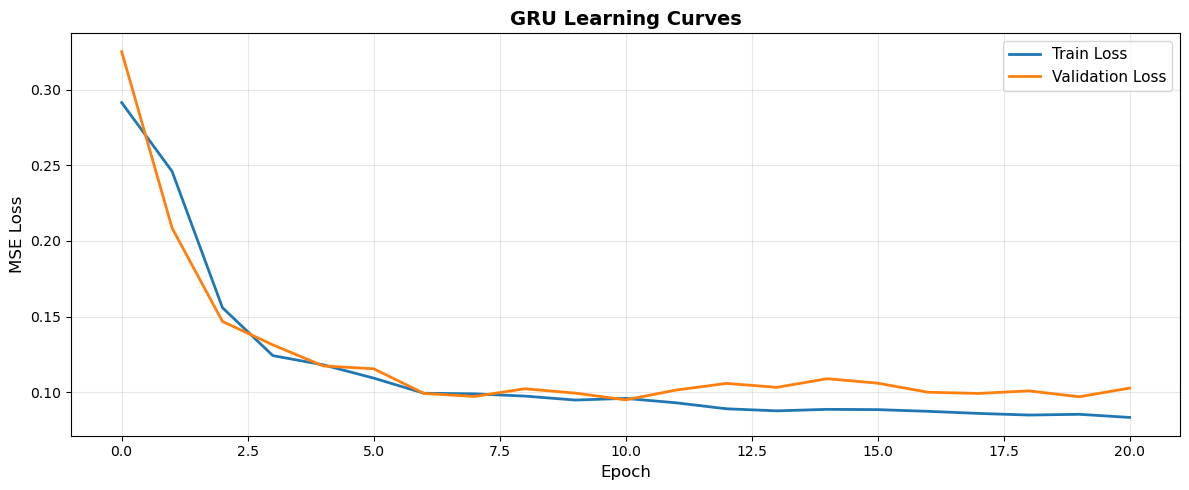

Saved: artifacts\figures\best_forecast_test.png


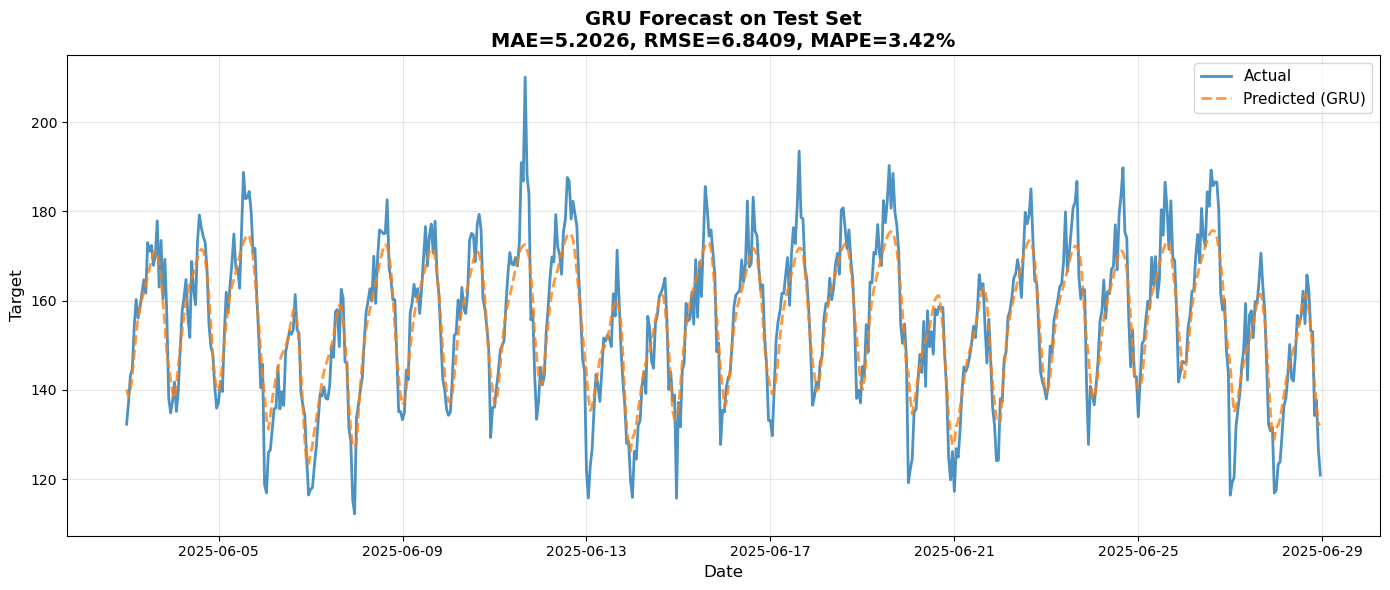


FINAL RESULTS
Best model: R1 (GRU)
Validation MAE: 4.5585
Test MAE:       5.2026

All artifacts saved to: artifacts/
  - runs.csv
  - best_gru.pt
  - best_gru_config.json
  - figures/baselines_compare.png
  - figures/gru_learning_curves.png
  - figures/best_forecast_test.png
  - figures/series_split.png

Cell 12 completed successfully.


In [12]:
print("="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)

test_loss_r1, test_preds_r1_scaled, test_targets_r1_scaled = evaluate(
    model, test_loader, criterion, device
)

test_mae_r1, test_rmse_r1, test_mape_r1 = calculate_metrics(
    test_preds_r1_scaled, test_targets_r1_scaled, scaler_target
)

print(f"Test MAE:  {test_mae_r1:.4f}")
print(f"Test RMSE: {test_rmse_r1:.4f}")
print(f"Test MAPE: {test_mape_r1:.2f}%")

results_df.loc[results_df['experiment_id'] == 'R1', 'test_mae'] = test_mae_r1
results_df.loc[results_df['experiment_id'] == 'R1', 'test_rmse'] = test_rmse_r1
results_df.loc[results_df['experiment_id'] == 'R1', 'test_mape'] = test_mape_r1

print("\n" + "="*70)
print("SAVING ARTIFACTS")
print("="*70)

runs_path = os.path.join(ARTIFACTS_DIR, 'runs.csv')
results_df.to_csv(runs_path, index=False)
print(f"Saved: {runs_path}")

model_path = os.path.join(ARTIFACTS_DIR, 'best_gru.pt')
torch.save(model.state_dict(), model_path)
print(f"Saved: {model_path}")

gru_config = {
    'experiment_id': 'R1',
    'seed': SEED,
    'input_size': INPUT_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'learning_rate': LEARNING_RATE,
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'batch_size': BATCH_SIZE,
    'epochs_trained': training_history['epochs_trained'],
    'feature_columns': feature_columns,
    'scaler_features': 'StandardScaler',
    'scaler_target': 'StandardScaler',
    'best_val_mae': float(val_mae_r1),
    'best_val_rmse': float(val_rmse_r1),
    'best_val_mape': float(val_mape_r1),
    'test_mae': float(test_mae_r1),
    'test_rmse': float(test_rmse_r1),
    'test_mape': float(test_mape_r1)
}

config_path = os.path.join(ARTIFACTS_DIR, 'best_gru_config.json')
with open(config_path, 'w') as f:
    json.dump(gru_config, f, indent=2)
print(f"Saved: {config_path}")

plt.figure(figsize=(12, 5))
plt.plot(training_history['train_losses'], label='Train Loss', linewidth=2)
plt.plot(training_history['val_losses'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('GRU Learning Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
learning_curves_path = os.path.join(FIGURES_DIR, 'gru_learning_curves.png')
plt.savefig(learning_curves_path, dpi=300)
print(f"Saved: {learning_curves_path}")
plt.show()

test_preds_original = scaler_target.inverse_transform(test_preds_r1_scaled)
test_targets_original = scaler_target.inverse_transform(test_targets_r1_scaled)

plt.figure(figsize=(14, 6))
plt.plot(test_df['date'].values[:len(test_targets_original)], test_targets_original.flatten(), 
         label='Actual', linewidth=2, alpha=0.8)
plt.plot(test_df['date'].values[:len(test_preds_original)], test_preds_original.flatten(), 
         label='Predicted (GRU)', linewidth=2, alpha=0.8, linestyle='--')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.title(f'GRU Forecast on Test Set\nMAE={test_mae_r1:.4f}, RMSE={test_rmse_r1:.4f}, MAPE={test_mape_r1:.2f}%', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
forecast_test_path = os.path.join(FIGURES_DIR, 'best_forecast_test.png')
plt.savefig(forecast_test_path, dpi=300)
print(f"Saved: {forecast_test_path}")
plt.show()

print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
print(f"Best model: R1 (GRU)")
print(f"Validation MAE: {val_mae_r1:.4f}")
print(f"Test MAE:       {test_mae_r1:.4f}")
print(f"\nAll artifacts saved to: {ARTIFACTS_DIR}/")
print(f"  - runs.csv")
print(f"  - best_gru.pt")
print(f"  - best_gru_config.json")
print(f"  - figures/baselines_compare.png")
print(f"  - figures/gru_learning_curves.png")
print(f"  - figures/best_forecast_test.png")
print(f"  - figures/series_split.png")

print("\nCell 12 completed successfully.")